<a href="https://colab.research.google.com/github/RichaGaharwar/Yulu---Hypothesis-Testing/blob/main/Yulu_Hypothesis_Testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# **About Yulu**
---

Yulu is India’s leading micro-mobility service provider, which offers unique vehicles for the daily commute. Starting off as a mission to eliminate traffic congestion in India, Yulu provides the safest commute solution through a user-friendly mobile app to enable shared, solo and sustainable commuting.

Yulu zones are located at all the appropriate locations (including metro stations, bus stands, office spaces, residential areas, corporate offices, etc) to make those first and last miles smooth, affordable, and convenient!

Yulu has recently suffered considerable dips in its revenues. They have contracted a consulting company to understand the factors on which the demand for these shared electric cycles depends. Specifically, they want to understand the factors affecting the demand for these shared electric cycles in the Indian market.

---
**Column Profiling:**

---

* datetime: datetime

* season: season (1: spring, 2: summer, 3: fall, 4: winter)

* holiday: whether day is a holiday or not

  (extracted from http://dchr.dc.gov/page/holiday-schedule)

* workingday: if day is neither weekend nor holiday is 1, otherwise is 0.

* weather:
  1) Clear, Few clouds, partly cloudy, partly cloudy
  2) Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
  3) Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
  4) Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog

* temp: temperature in Celsius

* atemp: feeling temperature in Celsius

* humidity: humidity

* windspeed: wind speed

* casual: count of casual users

* registered: count of registered users

* count: count of total rental bikes including both casual and registered


---
**How to begin:**

---

* Import the dataset and do usual exploratory data analysis steps like checking the structure & characteristics of the dataset

* Try establishing a relation between the dependent and independent variable (Dependent “Count” & Independent: Workingday, Weather, Season etc)

* Select an appropriate test to check whether:
Working Day has effect on number of electric cycles rented

  * No. of cycles rented similar or different in different seasons
  
  * No. of cycles rented similar or different in different weather

  * Weather is dependent on season (check between 2 predictor variable)

* Set up Null Hypothesis (H0)

* State the alternate hypothesis (H1)

* Check assumptions of the test (Normality, Equal Variance). You can check it using Histogram, Q-Q plot or statistical methods like levene’s test, Shapiro-wilk test (optional)

  * Please continue doing the analysis even If some assumptions fail (levene’s test or Shapiro-wilk test) but double check using visual analysis and report wherever necessary

* Set a significance level (alpha)

* Calculate test Statistics.

* Decision to accept or reject null hypothesis.

* Inference from the analysis

---
**Concept Used:**

---

* Bi-Variate Analysis

* 2-sample t-test: testing for difference across

* populations

* ANNOVA

* Chi-square

---
**Evaluation Criteria (50 Points):**

---

* Define Problem Statement and perform Exploratory Data Analysis (10 points)

  * Definition of problem (as per given problem statement with additional views)

  * Observations on shape of data, data types of all the attributes, conversion of categorical attributes to 'category' (If required) , missing value detection, statistical summary.

  * Univariate Analysis (distribution plots of all the continuous variable(s) barplots/countplots of all the categorical variables)

  * Bivariate Analysis (Relationships between important variables such as workday and count, season and count, weather and count.

  * Illustrate the insights based on EDA

    * Comments on range of attributes, outliers of various attributes

    * Comments on the distribution of the variables and relationship between them

    * Comments for each univariate and bivariate plots

* Hypothesis Testing (30 Points):

  * 2- Sample T-Test to check if Working Day has an effect on the number of electric cycles rented (10 points)

  * ANNOVA to check if No. of cycles rented is similar or different in different 1. weather 2. season (10 points)

  * Chi-square test to check if Weather is dependent on the season (10 points)

* Notebook Quality (10 points):
  * Structure & Flow
  * Well commented code

* What good looks like (distribution of 10 points):

  * Visual analysis (1)
  * Hypothesis formulation (1)
  * Select the appropriate test (1)
  * Check test assumptions (2)
  * Find the p-value(1)
  * Conclusion based on the p-value (2)

Yulu Cyan: #00D2FF

Yulu Teal: #0082A6

Yulu off-white: #F4F7F6

yulu grey: #707070

---
#**Problem Definition:**

---

Yulu, India's leading micro-mobility service provider, is facing a significant decline in revenue and needs to identify the core drivers of demand for its shared electric cycles within the Indian market.

The primary objective is to pinpoint which environmental, socioeconomic, or temporal variables (such as weather conditions, time of day, season, or user demographics) are statistically significant predictors of cycle utilization.

By quantifying how effectively these variables explain fluctuations in demand, Yulu aims to transition from a reactive operational model to a data-driven strategy— allowing them to optimize fleet distribution across Yulu Zones, refine dynamic pricing strategies, and ultimately reverse their current revenue dip through improved asset utilization.

---
# **EDA**

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
yulu = pd.read_csv("/content/yulu.csv", parse_dates= ['datetime'])
yulu.head(5)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [2]:
yulu.shape

(10886, 12)

**We have almost 11k records and 12 features in the dataset.**

In [3]:
yulu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(8)
memory usage: 1020.7 KB


---
**let's check which featutes need a change in datatypes.**

---

In [4]:
yulu['season'].unique()

array([1, 2, 3, 4])

In [5]:
yulu['holiday'].unique()

array([0, 1])

In [6]:
yulu['workingday'].unique()

array([0, 1])

In [7]:
yulu['weather'].unique()

array([1, 2, 3, 4])

* **features like: season, holiday, workingdays, weather needs to be changed to category datatype.**

In [8]:
yulu['season'] = yulu['season'].astype('category')
yulu['holiday'] = yulu['holiday'].astype('category')
yulu['workingday'] = yulu['workingday'].astype('category')
yulu['weather'] = yulu['weather'].astype('category')
yulu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  category      
 2   holiday     10886 non-null  category      
 3   workingday  10886 non-null  category      
 4   weather     10886 non-null  category      
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
dtypes: category(4), datetime64[ns](1), float64(3), int64(4)
memory usage: 723.7 KB


---
**Let's check if the dataset has any null values or not.**

---

In [22]:
yulu.isnull().any()

,0
datetime,False
season,False
holiday,False
workingday,False
weather,False
temp,False
atemp,False
humidity,False
windspeed,False
casual,False


* **No missing values found.**

---
**Let's look at the statistical summary of dataset.**

---

In [10]:
yulu.describe()

,datetime,temp,atemp,humidity,windspeed,casual,registered,count
count,10886,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2011-12-27 05:56:22.399411968,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
min,2011-01-01 00:00:00,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2011-07-02 07:15:00,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,2012-01-01 20:30:00,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,2012-07-01 12:45:00,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,2012-12-19 23:00:00,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000
std,NaN,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454


---
**Let's look for outliers**

---


In [11]:
# Calculate Interquartile Range (IQR)
Q1 = yulu['temp'].quantile(0.25)
Q3 = yulu['temp'].quantile(0.75)
IQR = Q3 - Q1

# Define boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out the outliers to inspect them
outliers = yulu[(yulu['temp'] < lower_bound) | (yulu['temp'] > upper_bound)]
print(f"Total outliers found in temp: {len(outliers)}")

Total outliers found in temp: 0


Total outliers found in temp: 0

In [12]:
# Calculate Interquartile Range (IQR)
Q1 = yulu['atemp'].quantile(0.25)
Q3 = yulu['atemp'].quantile(0.75)
IQR = Q3 - Q1

# Define boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out the outliers to inspect them
outliers = yulu[(yulu['atemp'] < lower_bound) | (yulu['atemp'] > upper_bound)]
print(f"Total outliers found in atemp: {len(outliers)}")

Total outliers found in atemp: 0


Total outliers found in atemp: 0

In [13]:
# Calculate Interquartile Range (IQR)
Q1 = yulu['humidity'].quantile(0.25)
Q3 = yulu['humidity'].quantile(0.75)
IQR = Q3 - Q1

# Define boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out the outliers to inspect them
outliers = yulu[(yulu['humidity'] < lower_bound) | (yulu['humidity'] > upper_bound)]
print(f"Total outliers found in humidity: {len(outliers)}")

Total outliers found in humidity: 22


Total outliers found in humidity: 22

In [14]:
# Calculate Interquartile Range (IQR)
Q1 = yulu['windspeed'].quantile(0.25)
Q3 = yulu['windspeed'].quantile(0.75)
IQR = Q3 - Q1

# Define boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out the outliers to inspect them
outliers = yulu[(yulu['windspeed'] < lower_bound) | (yulu['windspeed'] > upper_bound)]
print(f"Total outliers found in windspeed: {len(outliers)}")

Total outliers found in windspeed: 227


Total outliers found in windspeed: 227

In [15]:
# Calculate Interquartile Range (IQR)
Q1 = yulu['casual'].quantile(0.25)
Q3 = yulu['casual'].quantile(0.75)
IQR = Q3 - Q1

# Define boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out the outliers to inspect them
outliers = yulu[(yulu['casual'] < lower_bound) | (yulu['casual'] > upper_bound)]
print(f"Total outliers found in casual: {len(outliers)}")

Total outliers found in casual: 749


Total outliers found in casual: 749

In [16]:
# Calculate Interquartile Range (IQR)
Q1 = yulu['registered'].quantile(0.25)
Q3 = yulu['registered'].quantile(0.75)
IQR = Q3 - Q1

# Define boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out the outliers to inspect them
outliers = yulu[(yulu['registered'] < lower_bound) | (yulu['registered'] > upper_bound)]
print(f"Total outliers found in registered: {len(outliers)}")

Total outliers found in registered: 423


Total outliers found in registered: 423

In [17]:
# Calculate Interquartile Range (IQR)
Q1 = yulu['count'].quantile(0.25)
Q3 = yulu['count'].quantile(0.75)
IQR = Q3 - Q1

# Define boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out the outliers to inspect them
outliers = yulu[(yulu['count'] < lower_bound) | (yulu['count'] > upper_bound)]
print(f"Total outliers found in count: {len(outliers)}")

Total outliers found in count: 300


Total outliers found in count: 300

---
* **no outliers in temperature, atemp.**

  * Total outliers found in temp: 0
  * Total outliers found in atemp: 0

* **outliers detected in humidity, windspeed, casual, registered, count.**

  * Total outliers found in humidity: 22
  * Total outliers found in windspeed: 227
  * Total outliers found in casual: 749
  * Total outliers found in registered: 423
  * Total outliers found in count: 300

  ---

###**Univariate Analysis:**

In [18]:
yulu.columns

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count'],
      dtype='object')

**All features represented in one figure.**

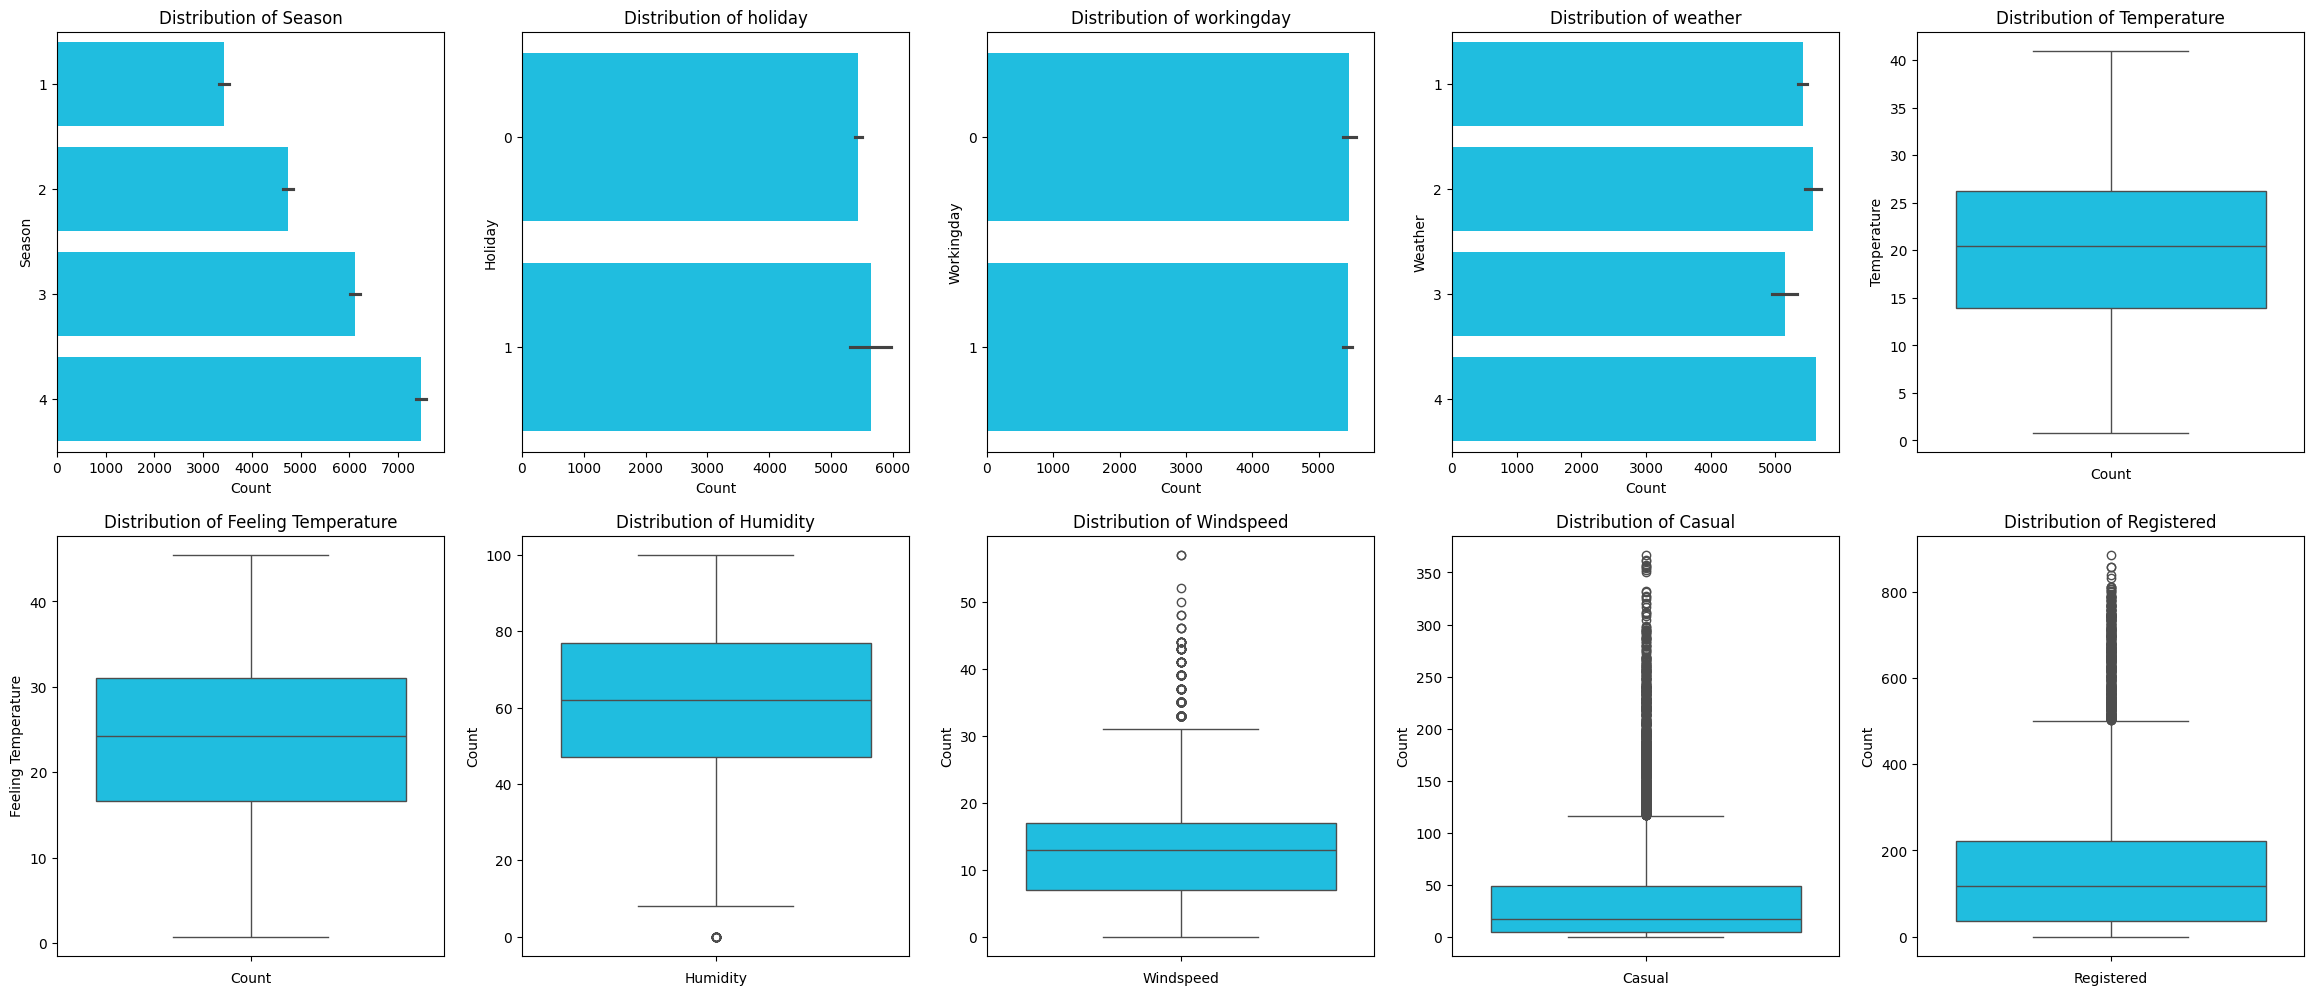

In [19]:
Yulu_Cyan = '#00D2FF'
plt.figure(figsize= (29,12))
plt.subplot(2,5,1)
sns.barplot(yulu['season'], color = Yulu_Cyan)
plt.title('Distribution of Season')
plt.xlabel('Count')
plt.ylabel('Season')

plt.subplot(2,5,2)
sns.barplot(yulu['holiday'], color = Yulu_Cyan)
plt.title('Distribution of holiday')
plt.xlabel('Count')
plt.ylabel('Holiday')

plt.subplot(2,5,3)
sns.barplot(yulu['workingday'], color = Yulu_Cyan)
plt.title('Distribution of workingday')
plt.xlabel('Count')
plt.ylabel('Workingday')

plt.subplot(2,5,4)
sns.barplot(yulu['weather'], color = Yulu_Cyan)
plt.title('Distribution of weather')
plt.xlabel('Count')
plt.ylabel('Weather')

plt.subplot(2,5,5)
sns.boxplot(yulu['temp'], color = Yulu_Cyan)
plt.title('Distribution of Temperature')
plt.xlabel('Count')
plt.ylabel('Temperature')

plt.subplot(2,5,6)
sns.boxplot(yulu['atemp'], color = Yulu_Cyan)
plt.title('Distribution of Feeling Temperature')
plt.xlabel('Count')
plt.ylabel('Feeling Temperature')

plt.subplot(2,5,7)
sns.boxplot(yulu['humidity'], color = Yulu_Cyan)
plt.title('Distribution of Humidity')
plt.xlabel('Humidity')
plt.ylabel('Count')

plt.subplot(2,5,8)
sns.boxplot(yulu['windspeed'], color = Yulu_Cyan)
plt.title('Distribution of Windspeed')
plt.xlabel('Windspeed')
plt.ylabel('Count')

plt.subplot(2,5,9)
sns.boxplot(yulu['casual'], color = Yulu_Cyan)
plt.title('Distribution of Casual')
plt.xlabel('Casual')
plt.ylabel('Count')

plt.subplot(2,5,10)
sns.boxplot(yulu['registered'], color = Yulu_Cyan)
plt.title('Distribution of Registered')
plt.xlabel('Registered')
plt.ylabel('Count')

plt.show()

**As detected before, features like: Humidity, Windspeed, Casual and Registered are showing outliers.**
**Let look deep into it.**

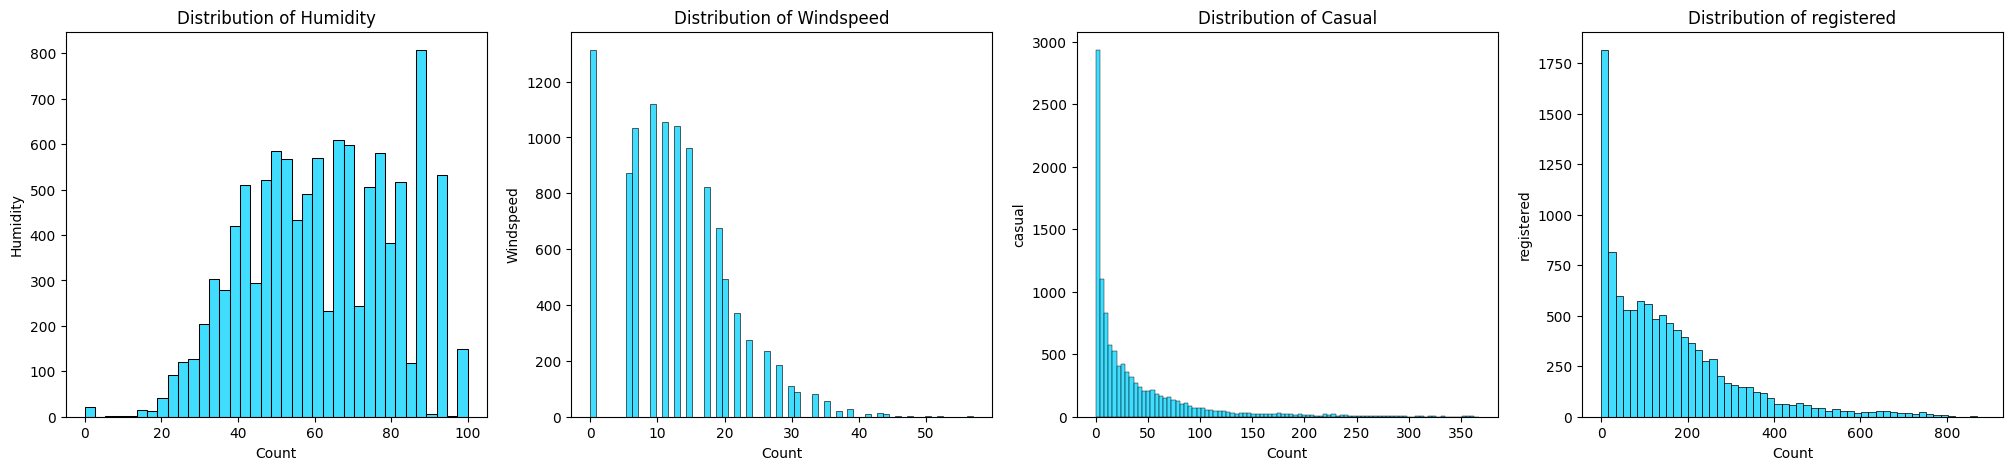

In [30]:
Yulu_Cyan = '#00D2FF'
plt.figure(figsize= (25,5))

plt.subplot(1,4,1)
sns.histplot(yulu['humidity'], color = Yulu_Cyan)
plt.title('Distribution of Humidity')
plt.xlabel('Count')
plt.ylabel('Humidity')

plt.subplot(1,4,2)
sns.histplot(yulu['windspeed'], color = Yulu_Cyan)
plt.title('Distribution of Windspeed')
plt.xlabel('Count')
plt.ylabel('Windspeed')

plt.subplot(1,4,3)
sns.histplot(yulu['casual'], color = Yulu_Cyan)
plt.title('Distribution of Casual')
plt.xlabel('Count')
plt.ylabel('casual')

plt.subplot(1,4,4)
sns.histplot(yulu['registered'], color = Yulu_Cyan)
plt.title('Distribution of registered')
plt.xlabel('Count')
plt.ylabel('registered')

plt.show()

**Outliers skew the data. In this case upper outliers in Windspeed, Casual & Registered are making the data right skewed and lower outlier in Humidity is making the data left skewed.**

###**Bivariate Analysis:**

Comments on range of attributes, outliers of various attributes

Comments on the distribution of the variables and relationship between them

Comments for each univariate and bivariate plots

2- Sample T-Test to check if Working Day has an effect on the number of electric cycles rented (10 points)

ANNOVA to check if No. of cycles rented is similar or different in different 1. weather 2. season (10 points)

Chi-square test to check if Weather is dependent on the season (10 points)